In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
airline=pd.read_csv('airline_cleaned.csv')

In [6]:
ml_data = airline.sample(100000, random_state=42)

In [7]:
X = ml_data[
    [
        "MONTH",
        "DAY_OF_WEEK",
        "OP_UNIQUE_CARRIER",
        "ORIGIN",
        "DEST",
        "CRS_DEP_TIME",
        "DISTANCE",
        "CRS_ELAPSED_TIME"
    ]
]

y = ml_data["ARR_DEL15"]

In [8]:
X = pd.get_dummies(
    X,
    columns=["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"],
    drop_first=True
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Accuracy: 0.7748

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87     16300
         1.0       0.24      0.10      0.14      3700

    accuracy                           0.77     20000
   macro avg       0.53      0.51      0.51     20000
weighted avg       0.71      0.77      0.74     20000



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [15]:
rf_pred = rf_model.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.77015

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.92      0.87     16300
         1.0       0.25      0.12      0.16      3700

    accuracy                           0.77     20000
   macro avg       0.53      0.52      0.51     20000
weighted avg       0.71      0.77      0.74     20000



In [17]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(15))

CRS_DEP_TIME            0.186080
DAY_OF_WEEK             0.158171
CRS_ELAPSED_TIME        0.134140
DISTANCE                0.080837
OP_UNIQUE_CARRIER_DL    0.007523
OP_UNIQUE_CARRIER_UA    0.006535
OP_UNIQUE_CARRIER_WN    0.006385
OP_UNIQUE_CARRIER_OO    0.004700
DEST_ORD                0.004689
DEST_ATL                0.004635
DEST_DFW                0.004458
OP_UNIQUE_CARRIER_NK    0.004419
DEST_DEN                0.004284
ORIGIN_DEN              0.004272
DEST_LAS                0.004221
dtype: float64


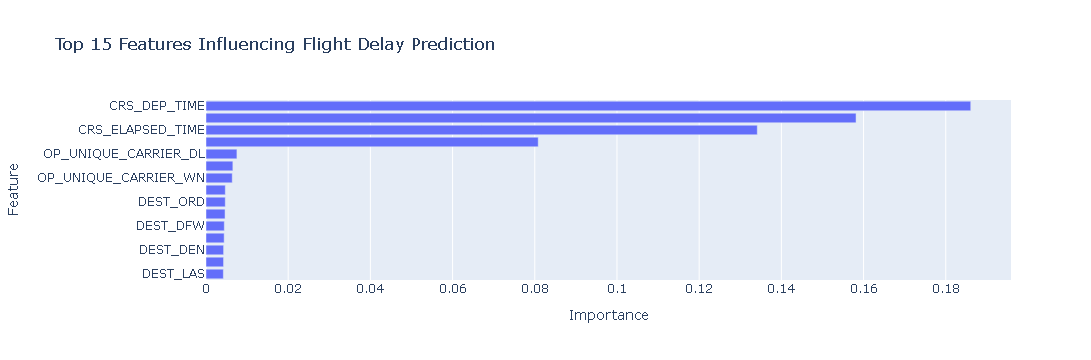

In [18]:
import plotly.express as px

top_features = importance.head(15).sort_values()

fig = px.bar(
    x=top_features.values,
    y=top_features.index,
    orientation="h",
    title="Top 15 Features Influencing Flight Delay Prediction",
    labels={
        "x": "Importance",
        "y": "Feature"
    }
)

fig.show()

In [19]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.596760172442381


In [21]:
import joblib

joblib.dump(rf_model, "airline_delay_random_forest.pkl")

['airline_delay_random_forest.pkl']

In [22]:
import joblib

joblib.dump(rf_model, "airline_delay_model.pkl")

['airline_delay_model.pkl']

In [23]:
metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
}

joblib.dump(metrics, "airline_ml_metrics.pkl")

['airline_ml_metrics.pkl']